<h1><b><center>Digital Terrain Models with GeoidLab</center></b></h1>
<p style="text-align: center; font-size: 1.1em; color: white;">
    Author: Caleb Kelly<br>
</p>

This notebook demonstrates the main terrain-modeling workflows exposed by `geoidlab.dtm`. The goal is to show how to

1. instantiate a `DigitalTerrainModel`,
2. synthesize heights at a single point,
3. synthesize heights over a regional grid,
4. create a quick global map, and
5. switch from the built-in DTM2006 model to another spherical-harmonic terrain model.

The examples are intentionally lightweight so that the notebook is easy to read and adapt. If this is your first time using the terrain tools in `geoidlab`, execute the cells from top to bottom.


# Directory Setup


In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({'font.family': 'Arial', 'font.size': 10})

work_dir = Path('GeoidProject')
downloads_dir = work_dir / 'downloads'
results_dir = work_dir / 'results'
figures_dir = results_dir / 'figures'

for path in [work_dir, downloads_dir, results_dir, figures_dir]:
    path.mkdir(parents=True, exist_ok=True)

results_dir, figures_dir


(PosixPath('GeoidProject/results'), PosixPath('GeoidProject/results/figures'))

# Imports


In [3]:
from geoidlab.dtm import DigitalTerrainModel


We will begin with the built-in DTM2006 terrain model. The `nmax` argument controls the maximum spherical-harmonic degree used during synthesis. Larger values capture shorter wavelengths, but they also increase computation time.


In [4]:
nmax = 222
dtm = DigitalTerrainModel(nmax=nmax)

Using compressed DTM2006.0 file in /Users/kelly/Documents/Github/geoidlab/geoidlab/data ...
Note: Maximum degree for DTM2006.0 is 2190


# A Single Point


The fastest way to get started is to synthesize the terrain height at one location. This is useful for quick checks before moving on to larger grids.


In [5]:
lon0, lat0 = -4.0, 10.0
height_point = dtm.dtm2006_height_point(lon=lon0, lat=lat0)
print(f'DTM2006 height at ({lon0:.2f}°, {lat0:.2f}°): {height_point:.3f} m')

DTM2006 height at (-4.00°, 10.00°): 258.598 m


# A Regional Grid


Now let us synthesize a small regional grid. A coarse grid keeps the example fast while still showing the spatial structure of the model.

Here we use a 1-degree spacing over West Africa. The method `dtm2006_height` accepts longitude and latitude grids directly, so `numpy.meshgrid` is enough to prepare the input.


In [6]:
resolution_deg = 1
lon_1d = np.arange(-20.0, 20.0 + resolution_deg, resolution_deg)
lat_1d = np.arange(0.0, 30.0 + resolution_deg, resolution_deg)
lon_grid, lat_grid = np.meshgrid(lon_1d, lat_1d)

lon_grid.shape, lat_grid.shape


((31, 41), (31, 41))

In [7]:
height_grid = dtm.dtm2006_height(
    lon=lon_grid,
    lat=lat_grid,
    chunk_size=800,
    save=False,
)

height_grid = np.asarray(height_grid).reshape(lon_grid.shape)
height_grid.shape


Computing chunks: 100%|██████████| 2/2 [00:02<00:00,  1.43s/it]


(31, 41)

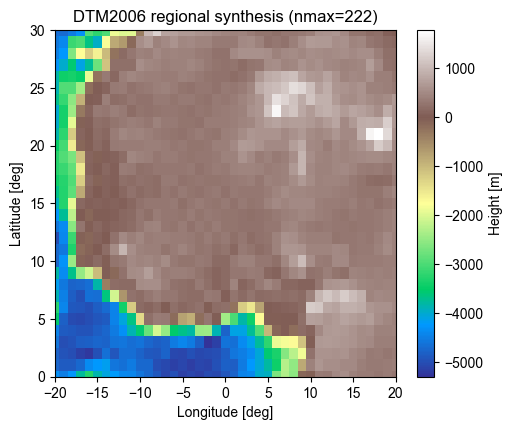

In [8]:
fig_name = figures_dir / 'dtm2006_regional_grid.png'

plt.figure(figsize=(5.5, 4.5))
plt.pcolormesh(lon_grid, lat_grid, height_grid, cmap='terrain', shading='auto')
plt.colorbar(label='Height [m]')
plt.xlabel('Longitude [deg]')
plt.ylabel('Latitude [deg]')
plt.title(f'DTM2006 regional synthesis (nmax={nmax})')
plt.xlim([-20, 20])
plt.ylim([0, 30])
# plt.savefig(fig_name, dpi=300, bbox_inches='tight')
plt.show()

A small summary is often useful before moving on to more expensive computations.


In [9]:
summary = pd.Series({
    'min_m': np.nanmin(height_grid),
    'max_m': np.nanmax(height_grid),
    'mean_m': np.nanmean(height_grid),
    'std_m': np.nanstd(height_grid),
})
summary


min_m    -5298.147952
max_m     1778.436920
mean_m    -550.575274
std_m     1845.507383
dtype: float64

# A Quick Global Example


To keep the runtime reasonable, we will use a 1-degree global grid and a modest harmonic degree. This is enough for a quick visual inspection of the synthesized topography and bathymetry.


In [10]:
import cartopy.crs as ccrs

In [11]:
global_nmax = 300
dtm_global = DigitalTerrainModel(nmax=global_nmax)

global_lon, global_lat = np.meshgrid(
    np.arange(-180.0, 181.0, 1.0),
    np.arange(-90.0, 91.0, 1.0),
)

global_height = dtm_global.dtm2006_height(
    lon=global_lon,
    lat=global_lat,
    chunk_size=800,
    leg_progress=False,
    n_workers=8,
)

global_height = np.asarray(global_height).reshape(global_lon.shape)
np.nanmin(global_height), np.nanmax(global_height), np.nanmean(global_height)


Using compressed DTM2006.0 file in /Users/kelly/Documents/Github/geoidlab/geoidlab/data ...
Note: Maximum degree for DTM2006.0 is 2190


Computing chunks: 100%|██████████| 82/82 [01:10<00:00,  1.17it/s]


(-8509.991692992518, 5621.892416054636, -1893.7715629240656)

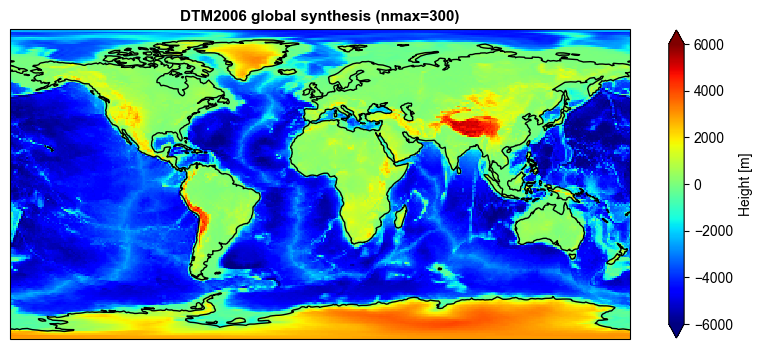

In [12]:
fig_name = figures_dir / 'dtm2006_global.png'

plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
pcm = ax.pcolormesh(
    global_lon,
    global_lat,
    global_height,
    cmap='jet',
    transform=ccrs.PlateCarree(),
    shading='auto',
    vmin=-6000,
    vmax=6000,
)
ax.coastlines()
ax.set_title(f'DTM2006 global synthesis (nmax={global_nmax})', fontsize=11, fontweight='bold')
plt.colorbar(pcm, orientation='vertical', shrink=0.8, label='Height [m]', extend='both')
# plt.savefig(fig_name, dpi=300, bbox_inches='tight')
plt.show()


# Switching to Another Terrain Model


`DigitalTerrainModel` is not limited to DTM2006. If you have another spherical-harmonic terrain model, you can pass its file path and format when constructing the object.

The example below uses the helper in `geoidlab.curtin` to download one of the Earth2014 models, then synthesizes heights with `synthesize_height`. If the model file already exists locally, `geoidlab` should reuse it.


In [13]:
from geoidlab.curtin import download_shc_model

In [14]:
model_path = download_shc_model(model='bed', resolution='5min')
model_path

PosixPath('downloads/Earth2014.BED2014.degree2160.bshc')

In [15]:
earth2014_bed = DigitalTerrainModel(
    model_name=model_path,
    nmax=300,
    model_format='bshc',
)

# earth2014_bed

Reading DTM file downloads/Earth2014.BED2014.degree2160.bshc ...


In [16]:
bed_height = earth2014_bed.synthesize_height(
    lon=global_lon,
    lat=global_lat,
    chunk_size=800,
    leg_progress=False,
    n_workers=8,
    save=False,
)

bed_height = np.asarray(bed_height).reshape(global_lon.shape)
np.nanmin(bed_height), np.nanmax(bed_height), np.nanmean(bed_height)


Computing chunks:   0%|          | 0/82 [00:00<?, ?it/s]OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
Computing chunks: 100%|██████████| 82/82 [00:33<00:00,  2.46it/s]


(-8500.688694294335, 5621.549309084724, -2124.8124892096203)

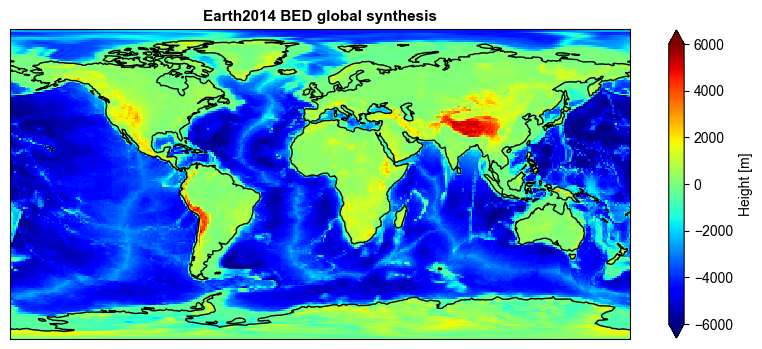

In [17]:
fig_name = figures_dir / 'earth2014_bed_global.png'

plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
pcm = ax.pcolormesh(
    global_lon,
    global_lat,
    bed_height,
    cmap='jet',
    transform=ccrs.PlateCarree(),
    shading='auto',
    vmin=-6000,
    vmax=6000,
)
ax.coastlines()
ax.set_title('Earth2014 BED global synthesis', fontsize=11, fontweight='bold')
plt.colorbar(pcm, orientation='vertical', shrink=0.8, label='Height [m]', extend='both')
# plt.savefig(fig_name, dpi=300, bbox_inches='tight')
plt.show()


# Remarks


This notebook covered the core `dtm.py` workflows in `geoidlab`:

- pointwise terrain synthesis with `dtm2006_height_point`,
- gridded synthesis with `dtm2006_height`,
- higher-degree evaluation with `calculate_height`, and
- custom-model synthesis with `synthesize_height`.

For practical work, the main knobs you will usually tune are `nmax`, `chunk_size`, and the size of the longitude-latitude grid. A good workflow is to prototype on a coarse grid first, then increase the resolution and harmonic degree once everything is behaving as expected.
